<a href="https://colab.research.google.com/github/mukeshrock7897/Artificial-Intelligence-Notes/blob/main/2_TSA(Time_Series_Analysis)_Intermediate_Level.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Intermediate Level**
1. Advanced Statistical Methods
    * Autoregressive Integrated Moving Average (ARIMA)
    * Seasonal ARIMA (SARIMA)
    * Exponential Smoothing State Space Model (ETS)

2. Time Series Decomposition
    * Additive and multiplicative decomposition
    * STL decomposition (Seasonal and Trend decomposition using Loess)

3. Forecasting Techniques
    * Forecasting with ARIMA and SARIMA models
    * Forecasting with ETS models
    * Comparing different forecasting methods

4. Model Evaluation and Validation
    * Train-test split
    * Cross-validation in time series
    * Evaluation metrics: MAE, MSE, RMSE, MAPE

5. Handling Missing Data
    * Interpolation methods
    * Forward and backward filling
    * Using statistical models to handle missing data

# **1.Advanced Statistical Methods**

**Autoregressive Integrated Moving Average (ARIMA):**

* A powerful statistical forecasting model for stationary time series data.
* It combines three components:
   * Autoregressive (AR): Considers the impact of past values (lags) on the forecast.
   * Integrated (I): Involves differencing the data to achieve stationarity (constant mean, variance, autocorrelation).
   * Moving Average (MA): Takes into account past forecast errors to improve accuracy.
* Requires identifying the appropriate order of AR and MA terms (p and q) using techniques like the Akaike Information Criterion (AIC) or the Bayesian Information Criterion (BIC).

In [2]:
from statsmodels.tsa.arima.model import ARIMA

# Sample data (replace with your actual data)
data = [10, 12, 15, 18, 17, 19, 21]

# Assuming stationarity has been achieved
model = ARIMA(data, order=(2, 1, 1))  # (p, d, q)
model_fit = model.fit()
forecast = model_fit.forecast(steps=1)  # Forecast for the next 1 time step

print(forecast)


[22.62310144]


/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


**Seasonal ARIMA (SARIMA):**

* An extension of ARIMA that incorporates seasonality into the model.
It includes additional parameters to account for seasonal effects (e.g., monthly seasonality).

In [4]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Sample data (replace with your actual data)
data = [10, 12, 15, 18, 17, 19, 21]
df = pd.DataFrame({'value': data}) # Create DataFrame from the data

# Fit SARIMA model
model_sarima = SARIMAX(df['value'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_sarima_fit = model_sarima.fit()

# Summary of the model
print(model_sarima_fit.summary())

# Forecast
forecast_sarima = model_sarima_fit.forecast(steps=10)
print(forecast_sarima)

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tools/eval_measures.py:414: RuntimeWarning: invalid value encountered in log
  return -2.0 * llf + np.log(nobs) * df_modelwc
/usr/local/lib/python3.10/dist-packages/statsmodels/tools/eval_measures.py:439: RuntimeWarning: invalid value encountered in log
  return -2.0 * llf + 2 * np.log(np.log(nobs)) * df_modelwc
/usr/local/lib/python3.10/dist-packages/statsmodels

                                     SARIMAX Results                                      
Dep. Variable:                              value   No. Observations:                    7
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                   0.000
Date:                            Sat, 06 Jul 2024   AIC                             10.000
Time:                                    11:50:10   BIC                                nan
Sample:                                         0   HQIC                               nan
                                              - 7                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1               0         -0        nan        nan           0           0
ma.L1               0         -0   

**Exponential Smoothing State Space Model (ETS)**
* ETS models capture trend, seasonality, and error components using exponential smoothing.

**Example:**

In [6]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit ETS model without seasonality
model_ets = ExponentialSmoothing(df['value'], trend='add', seasonal=None)  # Remove seasonal component
model_ets_fit = model_ets.fit()

# Summary of the model
print(model_ets_fit.summary())

# Forecast
forecast_ets = model_ets_fit.forecast(steps=10)
print(forecast_ets)

                       ExponentialSmoothing Model Results                       
Dep. Variable:                    value   No. Observations:                    7
Model:             ExponentialSmoothing   SSE                              6.250
Optimized:                         True   AIC                              7.207
Trend:                         Additive   BIC                              6.990
Seasonal:                          None   AICC                               inf
Seasonal Periods:                  None   Date:                 Sat, 06 Jul 2024
Box-Cox:                          False   Time:                         11:51:15
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level           1.4901e-08                alpha                 True
smoothing_trend           1.2107e-

# **2. Time Series Decomposition**

**Additive and Multiplicative Decomposition**
* **Additive:** Time series = Trend + Seasonality + Noise
* **Multiplicative:** Time series = Trend * Seasonality * Noise

**Example:**

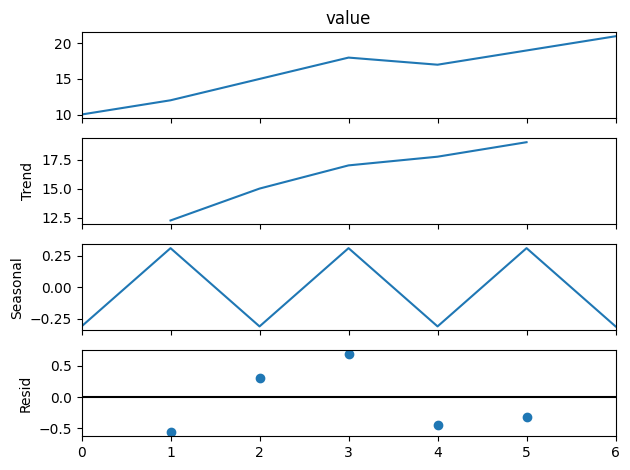

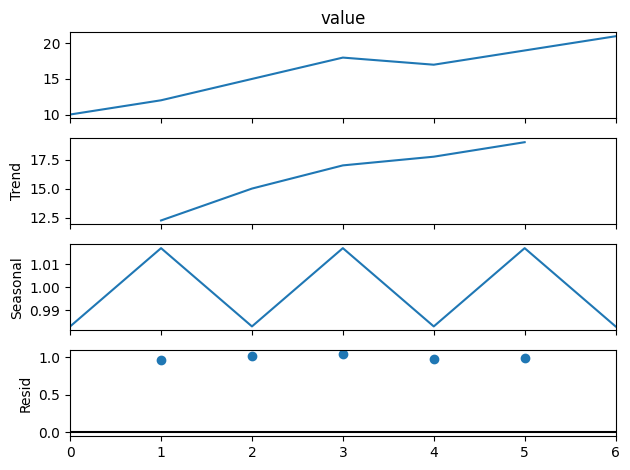

In [9]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


# Adjust the period to match the data availability
period_length = 2  # Example: Assuming a shorter cycle for demonstration

# Additive Decomposition
result_add = seasonal_decompose(df['value'], model='additive', period=period_length)
result_add.plot()
plt.show()

# Multiplicative Decomposition
result_mult = seasonal_decompose(df['value'], model='multiplicative', period=period_length)
result_mult.plot()
plt.show()

**STL Decomposition (Seasonal and Trend decomposition using Loess)**

* STL decomposes time series into seasonal, trend, and residual components using locally estimated scatterplot smoothing (Loess).

**Example:**

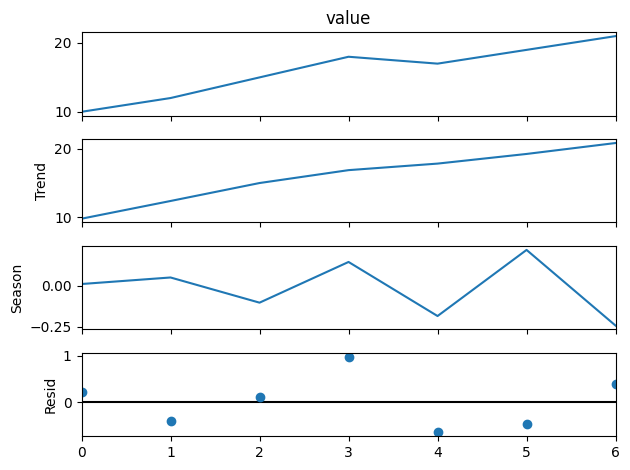

In [11]:
from statsmodels.tsa.seasonal import STL

# STL Decomposition
# Specify the period explicitly since it can't be inferred
stl = STL(df['value'], period=period_length, seasonal=13)  # Use the same period as in your seasonal decomposition
result_stl = stl.fit()
result_stl.plot()
plt.show()

# **3. Forecasting Techniques**

* Forecasting with ARIMA and SARIMA models

**Example:**



In [14]:
# Using ARIMA model
# Fit the ARIMA model first (if not already done)
model_fit = model.fit()

# Now you can forecast
forecast_arima = model_fit.forecast(steps=10)
print(forecast_arima)

# Using SARIMA model
forecast_sarima = model_sarima_fit.forecast(steps=10)
print(forecast_sarima)

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


[22.62310144 24.26342705 25.90052891 27.53547121 29.16820187 30.79872674
 32.42704864 34.05317057 35.67709549 37.29882637]
7     21.000000
8     21.000000
9     21.000000
10    21.000000
11    21.000000
12    26.000002
13    28.000002
14    31.000002
15    34.000002
16    33.000002
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


**Forecasting with ETS models**

**Example:**



In [15]:
# Using ETS model
forecast_ets = model_ets_fit.forecast(steps=10)
print(forecast_ets)

7     23.00
8     24.75
9     26.50
10    28.25
11    30.00
12    31.75
13    33.50
14    35.25
15    37.00
16    38.75
dtype: float64


**Comparing different forecasting methods**

**Example:**

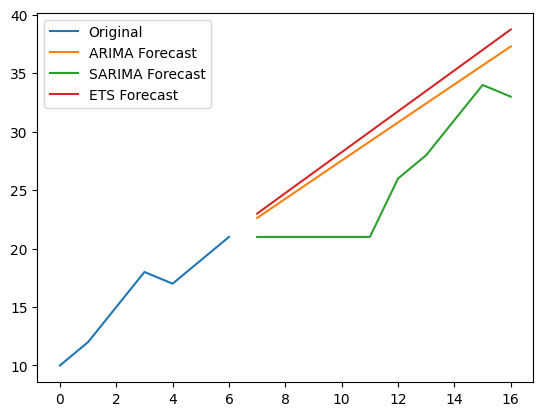

In [17]:
# Plot forecasts
plt.plot(df.index, df['value'], label='Original')
plt.plot(range(len(df), len(df) + len(forecast_arima)), forecast_arima, label='ARIMA Forecast') # Generating a range of indices for the forecasted values.
plt.plot(forecast_sarima.index, forecast_sarima, label='SARIMA Forecast')
plt.plot(forecast_ets.index, forecast_ets, label='ETS Forecast')
plt.legend()
plt.show()

# **4. Model Evaluation and Validation**

**Train-test split**

**Example:**

In [18]:
from sklearn.model_selection import train_test_split

# Train-test split
train, test = train_test_split(df['value'], test_size=0.2, shuffle=False)


**Cross-validation in time series**

**Example:**

In [19]:
from sklearn.model_selection import TimeSeriesSplit

# TimeSeriesSplit for cross-validation
tscv = TimeSeriesSplit(n_splits=5)
for train_index, test_index in tscv.split(df['value']):
    train, test = df['value'][train_index], df['value'][test_index]


**Evaluation metrics: MAE, MSE, RMSE, MAPE**

**Example:**

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

forecast_arima_last = forecast_arima[-1]
mae = mean_absolute_error([test], [forecast_arima_last])

# If 'forecast_arima' contains predictions matching the length of 'test' for the final split:
mae = mean_absolute_error(test, forecast_arima)

# Calculate MAE, MSE, RMSE, MAPE
mae = mean_absolute_error(test, forecast_arima)
mse = mean_squared_error(test, forecast_arima)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test - forecast_arima) / test)) * 100

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")


# **5. Handling Missing Data**

**Interpolation methods**

**Example:**

In [21]:
# Linear interpolation
df['value'].interpolate(method='linear', inplace=True)


**Forward and backward filling**

**Example:**

In [22]:
# Forward fill
df['value'].fillna(method='ffill', inplace=True)

# Backward fill
df['value'].fillna(method='bfill', inplace=True)


**Using statistical models to handle missing data**

**Example:**



In [23]:
# Imputing missing values with ARIMA model
model_arima = ARIMA(df['value'].fillna(0), order=(5,1,0))
model_arima_fit = model_arima.fit()
df['value'] = model_arima_fit.fittedvalues


/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
